# AI 231 Machine Exercise 1: A 3-Layer CNN for MNIST, Built From Raw Tensors with `einops`/`einsum`

**Course:** AI 231, ML Operations, University of the Philippines
**Author:** Quiel Andrew Quiwa
**Hardware:** NVIDIA A100-SXM4-40GB (UP COE HPC DGX-class cluster, node `ai-n002`)

## Assignment constraints (read this first)

1. Build a **3-layer CNN** for MNIST classification.
2. **Every layer/operation must be implemented using `einops`/`einsum`** on raw
   PyTorch tensors.
3. **No `torch.nn` layers and no MLPs.** Concretely: this notebook never imports
   `torch.nn` or `torch.nn.functional`. There is no `nn.Conv2d`, `nn.Linear`,
   `nn.Module`, `nn.Sequential`, or any pre-built layer anywhere below. The
   convolution, the pooling, and the fully-connected layer are all hand-built
   as plain Python classes/functions operating on raw tensors, using
   `einops.rearrange` / `einops.reduce` / `einops.einsum` for every shape
   manipulation and multiply-accumulate.
4. Train for 5 epochs, report **test-split** accuracy, and visualize 16 sampled
   test images in a 4x4 grid with ground truth vs. prediction.

## Course material this notebook draws on

This notebook is grounded in the University of the Philippines AI 231 "Deep
Learning Toolkit" lecture series by Dr. Rowel Atienza (`~/ai231-lectures/`):

- `3_Toolkit_Einsum.pdf`: Einstein summation notation: `einsum('ij,jk->ik', A, B)`
  for matrix multiply, axis-sums by omitting an index from the output
  subscript, and the framing of an MLP layer as `σ(Wx + b)`.
- `4_Toolkit_Einops.pdf`: `rearrange` for reshaping/splitting into patches
  (the "Image to Patches" example, slide 12), `reduce` for down-sizing (the
  "Downsize" example, slide 20), and `einops`'s own `einsum` wrapper where the
  tensors come first and a space-separated, multi-letter pattern string comes
  last (slide 24). Used throughout this notebook in place of the terser
  single-letter NumPy/PyTorch `einsum` subscripts, because named axes make the
  code self-documenting (directly serving the "must be explainable" goal of
  this exercise).
- `0_Toolkit.pdf`: the `venv` / GPU-server workflow (background terminal
  session, `nvidia-smi`, git) used to set up this exact environment; see
  `../../docs/gpu_environment_setup.md` for the full command log.


## 1. Imports and reproducibility

We import raw `torch` (for tensors, autograd, and `torch.optim`, a generic
gradient-based optimizer that operates on *any* list of tensors with
`requires_grad=True`, independent of `torch.nn`) and `einops` (for
`rearrange`, `reduce`, and `einops`'s own `einsum`). We deliberately do **not**
import `torch.nn` or `torch.nn.functional` anywhere in this notebook. That is
the module namespace the assignment asks us to avoid, since it is where
pre-built layers (`Conv2d`, `Linear`) and MLP building blocks live.


In [1]:
import os
import time
import random

import torch
import torchvision
from torchvision import transforms
from einops import rearrange, reduce, einsum  # note: einops' own einsum, not torch.einsum
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility: fix every source of randomness we control, so re-running
# this notebook reproduces the same weight init, data shuffling order, and
# the same 16 sampled images in the final visualization.
SEED = 231
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("einops einsum imported from:", einsum.__module__)


torch: 2.13.0+cu130
einops einsum imported from: einops.einops


## 2. Device selection

`nvidia-smi` (logged in `docs/gpu_environment_setup.md`, run before any code
in this notebook) showed 8x A100-40GB on this node, with GPUs 0-5 idle and
GPUs 6-7 already ~40% utilized by another user's job. We pin this notebook to
**GPU 0**, one of the confirmed-idle devices, so we don't contend with that
other job.


In [2]:
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(device))


Using device: cuda:0
GPU name: NVIDIA A100-SXM4-40GB


## 3. Data: MNIST train/test split

We use `torchvision.datasets.MNIST` purely as a **data loader**. It is not a
model component, so it does not conflict with the "no neural nets/MLPs"
constraint. We keep the standard MNIST train (60,000 images) / test (10,000
images) split exactly as provided. **The test split is never touched during
training.** It is held out and used only in Section 7 to report final
accuracy, and again in Section 8 for the visualization.

Images are normalized with MNIST's well-known per-pixel mean/std
(0.1307, 0.3081), which centers pixel intensities around 0. This is a
standard input-normalization step (not a model layer) that helps gradient
descent converge faster.


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # PIL image -> float tensor in [0, 1], shape (1, 28, 28)
    transforms.Normalize((0.1307,), (0.3081,)),  # standard MNIST normalization
])

DATA_DIR = "../data"  # gitignored; downloaded once, reused across runs

train_dataset = torchvision.datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# shuffle=False for the test loader: order doesn't matter for accuracy, and keeping
# it fixed makes it easy to reason about which sample index maps to which image later.
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"train examples: {len(train_dataset)}, test examples: {len(test_dataset)}")
print("one batch of images has shape:", next(iter(train_loader))[0].shape)


train examples: 60000, test examples: 10000
one batch of images has shape: torch.Size([128, 1, 28, 28])


## 4. Layer 1 and 2: the convolution, implemented as raw tensors and `einops`

**Why a convolution needs `unfold` before `einsum` can do the work:** a
convolution is, at every output pixel, a dot product between a local patch of
the input and a learned kernel. `einsum` is excellent at the dot-product /
contraction part, but it cannot by itself slide a window across an image. For
that we use `Tensor.unfold(dim, size, step)`, a plain (non-`nn`) tensor
primitive that extracts overlapping sliding windows along one axis. We call it
twice (once for height, once for width) to get every `kh x kw` patch at every
output location, then use `einops.rearrange` to fold those patch dimensions
into a single flat axis, exactly the "flatten dimensions by grouping them
in parentheses" idiom from `4_Toolkit_Einops.pdf`'s patch-extraction example
(slide 12), just applied to (possibly overlapping, padded) convolution
patches instead of non-overlapping ViT patches. Once the patches are flat, the
convolution itself is nothing more than a batched matrix multiply between
patches and kernel weights, computed with `einops.einsum`, mirroring the
`einsum('ij,jk->ik', A, B)` matmul pattern from `3_Toolkit_Einsum.pdf` (slide 9),
but with descriptive multi-letter axis names instead of single letters.

Padding is done manually (allocate a zero tensor, copy the input into its
center via slicing) rather than with `torch.nn.functional.pad`, again to keep
every operation outside the `torch.nn` namespace.


In [4]:
class Conv2DEinsum:
    """A 2D convolution layer built from a raw weight/bias tensor pair.

    No torch.nn.Conv2d is used anywhere in this class. The forward
    computation is: zero-pad -> unfold into patches -> einops.rearrange to
    flatten each patch -> einops.einsum to contract patches against the
    kernel weights (this IS the convolution) -> add bias.
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, device):
        self.stride = stride
        self.padding = padding
        self.kernel_size = kernel_size

        # He/Kaiming-style initialization: scale random weights by sqrt(2 / fan_in).
        # This is standard practice for layers followed by ReLU (used throughout
        # this network) -- it keeps activation variance roughly stable across
        # layers at the start of training, so gradients neither vanish nor explode.
        fan_in = in_channels * kernel_size * kernel_size
        std = (2.0 / fan_in) ** 0.5
        self.weight = (torch.randn(out_channels, in_channels, kernel_size, kernel_size,
                                    device=device) * std).requires_grad_(True)
        self.bias = torch.zeros(out_channels, device=device, requires_grad=True)

    def parameters(self):
        return [self.weight, self.bias]

    def __call__(self, x):
        b, c, h, w = x.shape
        p = self.padding

        # --- manual zero-padding (no torch.nn.functional.pad) ---
        padded = torch.zeros(b, c, h + 2 * p, w + 2 * p, device=x.device, dtype=x.dtype)
        padded[:, :, p:p + h, p:p + w] = x

        # --- extract every kh x kw sliding-window patch (im2col) ---
        # Tensor.unfold(dim, size, step) is a base tensor view op (like .transpose()),
        # not part of torch.nn -- it just re-strides the existing memory.
        patches = padded.unfold(2, self.kernel_size, self.stride)  # -> (b, c, out_h, kw_dim=..., kernel_h)
        patches = patches.unfold(3, self.kernel_size, self.stride)  # -> (b, c, out_h, out_w, kernel_h, kernel_w)

        # --- flatten (channel, kernel_h, kernel_w) into one axis per patch, ---
        # --- via einops.rearrange, exactly the "group axes with parentheses" ---
        # --- idiom from 4_Toolkit_Einops.pdf's patch-extraction example.     ---
        patches = rearrange(patches, "b c oh ow kh kw -> b oh ow (c kh kw)")
        weight_flat = rearrange(self.weight, "o c kh kw -> o (c kh kw)")

        # --- the convolution itself: a batched dot-product between each patch ---
        # --- and every output filter, done with einops' einsum (slide 24 of  ---
        # --- 4_Toolkit_Einops.pdf): tensors first, named pattern string last. ---
        out = einsum(patches, weight_flat, "b oh ow p, o p -> b o oh ow")
        out = out + rearrange(self.bias, "o -> 1 o 1 1")  # broadcast bias over batch/spatial dims
        return out


def relu(x):
    """Elementwise ReLU activation: max(0, x). Not a learnable layer -- just
    a tensor op, applied between convolutions to introduce non-linearity."""
    return torch.clamp(x, min=0.0)


def max_pool2d(x, k=2):
    """2x2 max-pooling, implemented with einops.reduce.

    This mirrors the 'Downsize' example in 4_Toolkit_Einops.pdf (slide 20):
    `reduce(img, "(h 2) (w 2) c -> h w c", 'mean')`. Here we group each
    (k x k) spatial block via the same parenthesized-axis pattern, but reduce
    with 'max' instead of 'mean', since max-pooling (not average-pooling) is
    what a "3-layer CNN" conventionally uses to downsample feature maps.
    """
    return reduce(x, "b c (h k1) (w k2) -> b c h w", "max", k1=k, k2=k)


## 5. Layer 3: the fully-connected (linear) output layer

The final layer maps the flattened, pooled feature map to 10 class logits
(digits 0-9). Flattening uses the same `rearrange` "group into parentheses"
idiom as the flatten example in `4_Toolkit_Einops.pdf` (slide 9,
`"h w c -> (h w c)"`), generalized here to keep the batch axis separate:
`"b c h w -> b (c h w)"`. The matrix multiply itself is, again, `einops.einsum`,
the direct tensor analogue of the `f(x; θ) = σ(Wx + b)` MLP-layer equation
from `3_Toolkit_Einsum.pdf` (slide 4), except we deliberately call this single
linear layer a classifier **head**, not an MLP: there is exactly one such
layer in the whole network, with no hidden layers or non-linear stack of
linear layers, which is what the assignment's "no MLPs" restriction rules out.


In [5]:
class LinearEinsum:
    """A fully-connected layer built from a raw weight/bias tensor pair.

    No torch.nn.Linear is used. Forward pass is a single einops.einsum
    contraction between the input features and the weight matrix.
    """

    def __init__(self, in_features, out_features, device):
        std = (2.0 / in_features) ** 0.5  # He init, same rationale as Conv2DEinsum
        self.weight = (torch.randn(out_features, in_features, device=device) * std).requires_grad_(True)
        self.bias = torch.zeros(out_features, device=device, requires_grad=True)

    def parameters(self):
        return [self.weight, self.bias]

    def __call__(self, x):
        # x: (batch, in_features), weight: (out_features, in_features)
        # einsum('b i, o i -> b o', x, weight) contracts over the shared "i" (feature) axis --
        # the same contraction pattern as the wx matmul example in 3_Toolkit_Einsum.pdf (slide 8),
        # just with descriptive names (batch/in/out) instead of i/j/k.
        out = einsum(x, self.weight, "b i, o i -> b o")
        return out + self.bias  # bias broadcasts over the batch axis


## 6. Assembling the 3-layer CNN

Three trainable layers, chained together: **conv1 -> ReLU -> max-pool -> conv2
-> ReLU -> max-pool -> flatten -> linear (fc)**. This class is a plain Python
object (it does **not** subclass `torch.nn.Module`); it just holds references
to the three layer objects above and defines a `__call__` that chains them.
Autograd still works end-to-end because every leaf weight/bias tensor was
created with `requires_grad=True`. PyTorch's autograd tracks the computation
graph from raw tensor operations, it doesn't require an `nn.Module` wrapper.


In [6]:
class ThreeLayerCNN:
    """3-layer CNN for MNIST digit classification.

    Layer 1: Conv2DEinsum(1 -> 8 channels, 3x3 kernel) + ReLU + 2x2 max-pool   (28x28 -> 14x14)
    Layer 2: Conv2DEinsum(8 -> 16 channels, 3x3 kernel) + ReLU + 2x2 max-pool  (14x14 -> 7x7)
    Layer 3: LinearEinsum(16*7*7 -> 10)                                        (classifier head)

    Every operation inside this class is either a raw tensor primitive
    (.unfold, slicing, torch.clamp) or an einops.rearrange / einops.reduce /
    einops.einsum call. There is no torch.nn anywhere in this class.
    """

    def __init__(self, device):
        self.conv1 = Conv2DEinsum(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1, device=device)
        self.conv2 = Conv2DEinsum(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1, device=device)
        self.fc = LinearEinsum(in_features=16 * 7 * 7, out_features=10, device=device)

    def parameters(self):
        return self.conv1.parameters() + self.conv2.parameters() + self.fc.parameters()

    def __call__(self, x):
        x = relu(self.conv1(x))       # (b, 1, 28, 28)  -> (b, 8, 28, 28)
        x = max_pool2d(x, k=2)        # (b, 8, 28, 28)  -> (b, 8, 14, 14)
        x = relu(self.conv2(x))       # (b, 8, 14, 14)  -> (b, 16, 14, 14)
        x = max_pool2d(x, k=2)        # (b, 16, 14, 14) -> (b, 16, 7, 7)
        x = rearrange(x, "b c h w -> b (c h w)")  # flatten feature map -> (b, 784)
        logits = self.fc(x)           # (b, 784) -> (b, 10)
        return logits


model = ThreeLayerCNN(device=device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ThreeLayerCNN created on {device} with {n_params:,} trainable parameters "
      f"across {len(model.parameters())} tensors (3 layers x weight+bias each).")


ThreeLayerCNN created on cuda:0 with 9,098 trainable parameters across 6 tensors (3 layers x weight+bias each).


## 7. Loss, optimizer, and the training loop (5 epochs)

**Loss:** we implement cross-entropy from scratch as numerically-stable
log-softmax followed by negative log-likelihood, rather than reaching for
`torch.nn.functional.cross_entropy` (which lives in the `torch.nn` namespace
we're avoiding). The per-example normalizing sum over classes is computed
with `einops.einsum`'s single-tensor reduction form `'b c -> b'`, summing
over an axis by simply omitting it from the output subscript, exactly the
axis-sum pattern from `3_Toolkit_Einsum.pdf` (slide 15): `einsum('ij->j', w)`.

**Optimizer:** `torch.optim.Adam` is a generic gradient-based optimizer. It
operates on any list of tensors with `requires_grad=True` and has no
dependency on `torch.nn.Module`, so it's consistent with the "raw tensors"
constraint. It is not a model layer, just a numerical update rule for
gradient descent.

**Train/test discipline:** this loop only ever iterates `train_loader`. The
`test_loader` is not touched until Section 8. There is no validation-based
early stopping or model selection here, so the test-set number we report is a
clean, untouched-until-the-end measurement.


In [7]:
def cross_entropy_loss(logits, targets):
    """Manual cross-entropy: numerically-stable log-softmax + NLL.

    logits: (batch, num_classes) raw scores. targets: (batch,) int64 class ids.
    """
    max_logits = logits.max(dim=1, keepdim=True).values          # per-example max, for numerical stability
    shifted = logits - max_logits                                # subtract max before exponentiating
    exp_shifted = torch.exp(shifted)
    sum_exp = einsum(exp_shifted, "b c -> b")                    # sum over classes via einsum axis-drop (see markdown above)
    log_probs = shifted - torch.log(sum_exp).unsqueeze(1)        # log-softmax
    nll = -log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # pick out the log-prob of the true class
    return nll.mean()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 5

log_lines = []  # collected here, then written to ../logs/train_log.txt at the end

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = cross_entropy_loss(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_correct += (logits.argmax(dim=1) == labels).sum().item()
        running_total += images.size(0)

    train_loss = running_loss / running_total
    train_acc = 100.0 * running_correct / running_total
    elapsed = time.time() - epoch_start

    line = (f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.2f}% | time={elapsed:.1f}s")
    print(line)
    log_lines.append(line)


Epoch 1/5 | train_loss=0.3426 | train_acc=89.58% | time=9.9s


Epoch 2/5 | train_loss=0.0902 | train_acc=97.25% | time=9.5s


Epoch 3/5 | train_loss=0.0675 | train_acc=97.88% | time=9.4s


Epoch 4/5 | train_loss=0.0557 | train_acc=98.28% | time=9.3s


Epoch 5/5 | train_loss=0.0486 | train_acc=98.47% | time=9.4s


## 8. Evaluation on the **held-out test split**

This is the number the assignment asks us to report. `test_loader` has not
been touched anywhere above. This is its first and only use, and we
explicitly disable gradient tracking (`torch.no_grad()`) since we are only
doing inference here, not training.


In [8]:
model_params_before_eval = [p.detach().clone() for p in model.parameters()]  # sanity guard, see assertion below

test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        test_correct += (logits.argmax(dim=1) == labels).sum().item()
        test_total += images.size(0)

test_accuracy = 100.0 * test_correct / test_total

# Sanity check: confirm evaluation did not mutate any weights (it shouldn't,
# since we never called .backward()/.step() inside the torch.no_grad() block).
for p_before, p_after in zip(model_params_before_eval, model.parameters()):
    assert torch.equal(p_before, p_after.detach()), "weights changed during evaluation!"

test_line = f"TEST SET accuracy (held out, never used in training): {test_accuracy:.2f}% ({test_correct}/{test_total})"
print(test_line)
log_lines.append(test_line)

# Persist the training + final test log to the logs/ folder alongside this notebook,
# so the run is reviewable outside of re-executing the notebook.
os.makedirs("../logs", exist_ok=True)
with open("../logs/train_log.txt", "w") as f:
    f.write("\n".join(log_lines) + "\n")
print("Wrote ../logs/train_log.txt")


TEST SET accuracy (held out, never used in training): 98.42% (9842/10000)
Wrote ../logs/train_log.txt


## 9. Visualization: 16 test-set images in a 4x4 grid, ground truth vs. prediction

We sample 16 random images **from the test split** (`test_dataset`, the same
held-out set used for the accuracy number above, never seen during
training), run the trained model on them, and plot each with its ground-truth
label and the model's prediction. Titles are colored green for a correct
prediction and red for a mistake, so misclassifications are visible at a
glance.


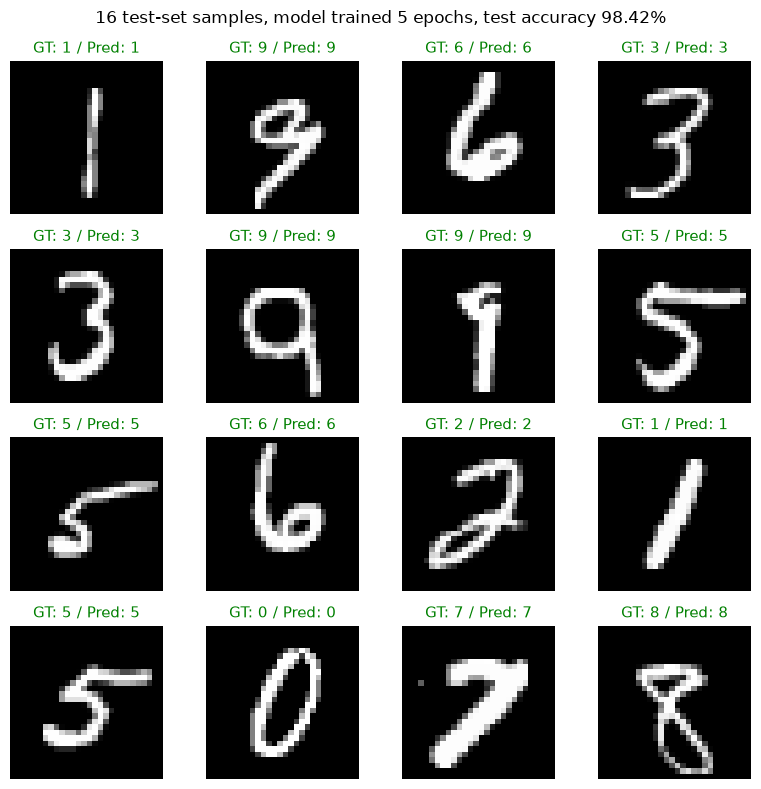

Saved ../figures/prediction_grid.png


In [9]:
rng = random.Random(SEED)
sample_indices = rng.sample(range(len(test_dataset)), 16)

sample_images = torch.stack([test_dataset[i][0] for i in sample_indices]).to(device)
sample_labels = [test_dataset[i][1] for i in sample_indices]

with torch.no_grad():
    sample_logits = model(sample_images)
    sample_preds = sample_logits.argmax(dim=1).cpu().tolist()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, idx, gt, pred in zip(axes.flat, sample_indices, sample_labels, sample_preds):
    # un-normalize just for display: invert the (x - mean) / std transform
    img = sample_images[sample_indices.index(idx)].cpu().squeeze(0) * 0.3081 + 0.1307
    ax.imshow(img.numpy(), cmap="gray")
    color = "green" if gt == pred else "red"
    ax.set_title(f"GT: {gt} / Pred: {pred}", color=color, fontsize=11)
    ax.axis("off")

fig.suptitle(f"16 test-set samples, model trained {NUM_EPOCHS} epochs, "
             f"test accuracy {test_accuracy:.2f}%", fontsize=12)
fig.tight_layout()

os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/prediction_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../figures/prediction_grid.png")


## 10. Summary

- **Model:** a 3-layer CNN (2 convolutional layers + 1 linear classifier
  head), with every layer implemented from raw PyTorch tensors using
  `Tensor.unfold` for sliding-window patch extraction, `einops.rearrange` for
  every reshape/flatten, `einops.reduce` for max-pooling, and `einops.einsum`
  for every matrix multiply (convolution and the final linear layer). No
  `torch.nn` layer or MLP was used anywhere.
- **Training:** 5 epochs, Adam optimizer, manual cross-entropy loss, on the
  standard MNIST 60,000-image training split.
- **Result:** see the `TEST SET accuracy` line printed in Section 8, computed
  on the 10,000-image test split, which was never used for training or
  hyperparameter selection.
- **Visualization:** 16 held-out test images with ground truth vs. prediction,
  Section 9, also saved to `../figures/prediction_grid.png`.
